<a href="https://colab.research.google.com/github/sherifudeenusman-jpg/Python-Program-OIBSIP/blob/main/house_price_of_unit_area_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [ ]:
import pandas as pd
df = pd.read_csv('Azure02_02_Angel Real Estate Data (1).csv')

In [ ]:
df.head(10)

,No,transaction_date,house_age,distance_to_bus_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10.0,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9.0,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5.0,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5.0,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5.0,24.97937,121.54245,43.1
5,6,2012.667,7.1,2175.03000,3.0,24.96305,121.51254,32.1
6,7,2012.667,34.5,623.47310,7.0,24.97933,121.53642,40.3
7,8,2013.417,20.3,287.60250,6.0,24.98042,121.54228,46.7
8,9,2013.500,31.7,5512.03800,1.0,24.95095,121.48458,18.8
9,10,2013.417,17.9,1783.18000,3.0,24.96731,121.51486,22.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   No                            414 non-null    int64  
 1   transaction_date              414 non-null    float64
 2   house_age                     414 non-null    float64
 3   distance_to_bus_station       407 non-null    float64
 4   number_of_convenience_stores  407 non-null    float64
 5   latitude                      414 non-null    float64
 6   longitude                     414 non-null    float64
 7   house_price_of_unit_area      414 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 26.0 KB


### Handling Missing Values

As observed from `df.info()`, the columns `distance_to_bus_station` and `number_of_convenience_stores` each have 7 missing values. For numerical features, a common strategy to handle missing values is to impute them with the mean of the respective column. This helps maintain the overall distribution of the data while filling in the gaps.

In [ ]:
# Impute missing values in 'distance_to_bus_station' with its mean
df['distance_to_bus_station'] = df['distance_to_bus_station'].fillna(df['distance_to_bus_station'].mean())

# Impute missing values in 'number_of_convenience_stores' with its mean
df['number_of_convenience_stores'] = df['number_of_convenience_stores'].fillna(df['number_of_convenience_stores'].mean())

print("Missing values handled.")

Missing values handled.


Let's verify that the missing values have been successfully handled by checking `df.info()` again.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   No                            414 non-null    int64  
 1   transaction_date              414 non-null    float64
 2   house_age                     414 non-null    float64
 3   distance_to_bus_station       414 non-null    float64
 4   number_of_convenience_stores  414 non-null    float64
 5   latitude                      414 non-null    float64
 6   longitude                     414 non-null    float64
 7   house_price_of_unit_area      414 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 26.0 KB


## Linear Regression (OLS and Online Gradient Descent)

### Ordinary Least Squares (OLS)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
# We'll drop 'No' and 'transaction_date' as they are not typically used as direct features in this type of regression
X = df.drop(['No', 'transaction_date', 'house_price_of_unit_area'], axis=1)
y = df['house_price_of_unit_area']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the OLS Linear Regression model
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ols = ols_model.predict(X_test)

# Evaluate the model
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print(f"OLS Mean Squared Error: {mse_ols:.2f}")
print(f"OLS R-squared: {r2_ols:.2f}")

# Display coefficients
print("\nOLS Model Coefficients:")
for feature, coef in zip(X.columns, ols_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {ols_model.intercept_:.4f}")

OLS Mean Squared Error: 54.60
OLS R-squared: 0.67

OLS Model Coefficients:
  house_age: -0.2787
  distance_to_bus_station: -0.0044
  number_of_convenience_stores: 1.1020
  latitude: 243.0621
  longitude: -12.0003
  Intercept: -4567.2710


### Online Gradient Descent (Stochastic Gradient Descent Regression)

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Standardize features for SGD, which is sensitive to feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SGD Regressor model (Online Gradient Descent)
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_sgd = sgd_model.predict(X_test_scaled)

# Evaluate the model
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print(f"SGD Mean Squared Error: {mse_sgd:.2f}")
print(f"SGD R-squared: {r2_sgd:.2f}")

# Display coefficients (note: these are for scaled features)
print("\nSGD Model Coefficients (for scaled features):")
for feature, coef in zip(X.columns, sgd_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {sgd_model.intercept_[0]:.4f}")

SGD Mean Squared Error: 54.28
SGD R-squared: 0.68

SGD Model Coefficients (for scaled features):
  house_age: -3.1506
  distance_to_bus_station: -4.8825
  number_of_convenience_stores: 3.2882
  latitude: 3.1064
  longitude: 0.1153
  Intercept: 38.4054


## Boosted Decision Tree Regression

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Gradient Boosting Regressor model
# Using default parameters for now, but these can be tuned.
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate the model
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting Regressor Mean Squared Error: {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor Mean Squared Error: 33.30
Gradient Boosting Regressor R-squared: 0.80


## Decision Forest Regression (Random Forest Regressor)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Random Forest Regressor model
# Using default parameters for now, but these can be tuned.
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regressor R-squared: {r2_rf:.2f}")

Random Forest Regressor Mean Squared Error: 32.89
Random Forest Regressor R-squared: 0.80


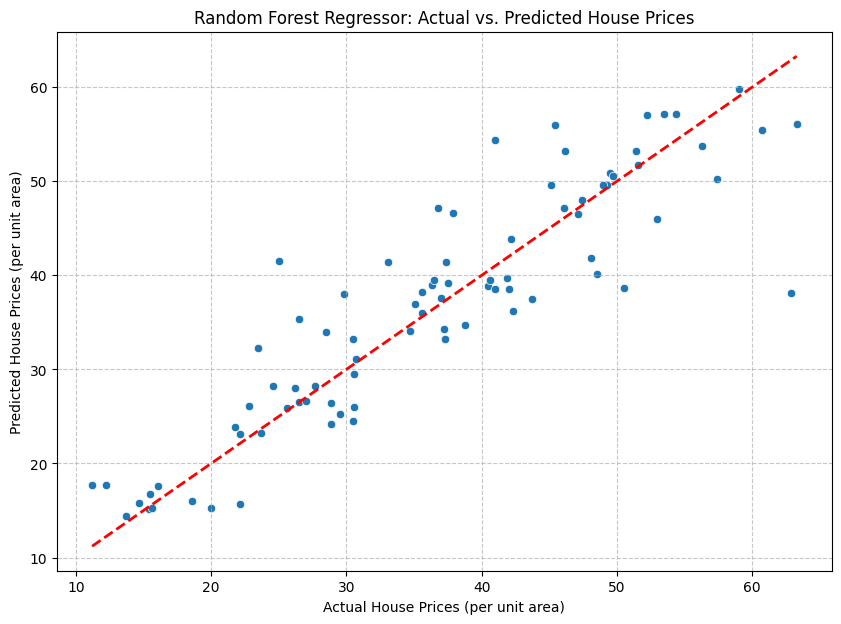

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual House Prices (per unit area)")
plt.ylabel("Predicted House Prices (per unit area)")
plt.title("Random Forest Regressor: Actual vs. Predicted House Prices")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

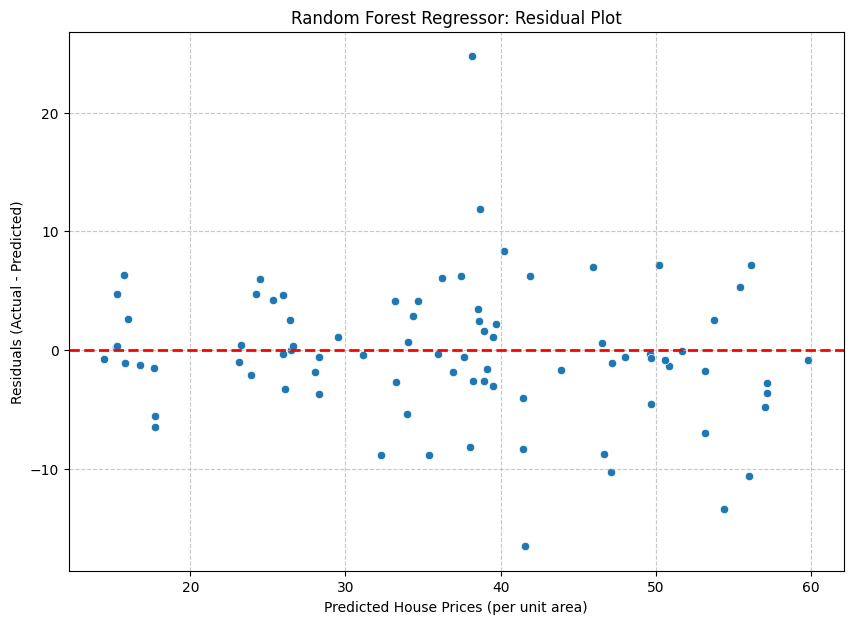

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Add a horizontal line at 0
plt.xlabel("Predicted House Prices (per unit area)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Random Forest Regressor: Residual Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Calculate RMSE for each model
rmse_ols = np.sqrt(mse_ols)
rmse_sgd = np.sqrt(mse_sgd)
rmse_gbr = np.sqrt(mse_gbr)
rmse_rf = np.sqrt(mse_rf)

# Create a DataFrame to store all model metrics
metrics_data = {
    'Model': ['OLS Linear Regression', 'SGD Linear Regression', 'Gradient Boosting Regressor', 'Random Forest Regressor'],
    'MSE': [mse_ols, mse_sgd, mse_gbr, mse_rf],
    'RMSE': [rmse_ols, rmse_sgd, rmse_gbr, rmse_rf],
    'R-squared': [r2_ols, r2_sgd, r2_gbr, r2_rf]
}

metrics_df = pd.DataFrame(metrics_data)

# Sort by RMSE to easily identify the best model
metrics_df = metrics_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

display(metrics_df)

print(f"\nThe best-performing model based on RMSE and R-squared is: {metrics_df.iloc[0]['Model']}")

,Model,MSE,RMSE,R-squared
0,Random Forest Regressor,32.888115,5.734816,0.803957
1,Gradient Boosting Regressor,33.302438,5.770826,0.801487
2,SGD Linear Regression,54.277016,7.367294,0.676460
3,OLS Linear Regression,54.602954,7.389381,0.674517



The best-performing model based on RMSE and R-squared is: Random Forest Regressor


This command installs the `pandas` library. Replace `pandas` with the name of any other library you wish to install.